In [1]:
%matplotlib widget
import numpy as np
from numpy import abs
import matplotlib.pyplot as plt
from scipy.special import eval_genlaguerre
import ipywidgets as widgets

There is no analytical expression for the Classical Fisher Information in the case of seeded parametric down-conversion. Instead it is necessary to compute it as

\begin{equation}
F_C=\sum_m\frac{1}{p_m}\left(\frac{\partial p_m}{\partial\varphi}\right)^2,
\end{equation}

where the analytical expressions of both $p_m$ and $\partial p_m/\partial\varphi$ are known (eqs. 4.19 and 4.20 in thesis manuscript, respectively). This notebook computes the summands that add up to $F_c$ (up to a given $m_{Max}$) for a single combination of parameters $\varphi$, $G$, $\tau$ and $\alpha$.

The dynamical widget in this notebook helps visualize why it is difficult to compute the Classical Fisher Information for high values of $G$ and $\alpha$, since as these quantities increase, so does the number of summands that is necessary to compute before the sum tends to a constant value.

Since summands tends to zero as the value of $m$ increases, numpy eventually runs into numerical precission limitations when computing the classical Fisher information. This is why it eventually becomes necessary to rely on an arbitrary precision arithmetic package (mpmath).

interactive(children=(FloatSlider(value=100.0, description='mMax:', max=5000.0, min=1.0, step=100.0), FloatSli…

<function __main__.update_plot(mMax=10, phi=1.5707963267948966, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1)>

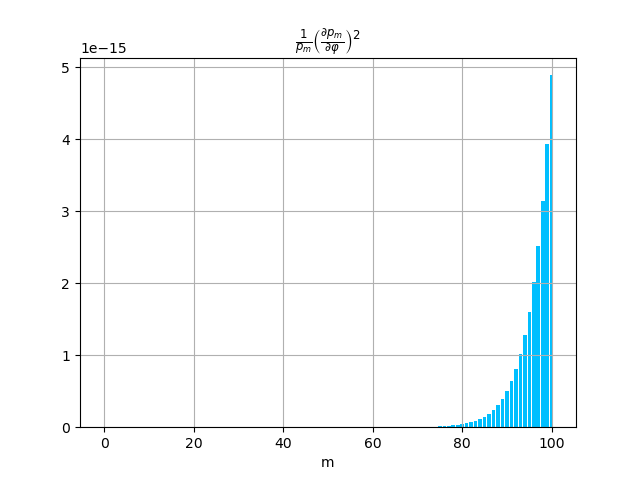

In [2]:
fig,ax = plt.subplots()

def Fisher_Summands(mMax, phi=np.pi/2, G=0.5, a_i=0, t_s1=1, t_i1=1, t_s2=1): 

    U=np.cosh(G)
    V=np.sinh(G)
    
    #* Average number of output signal photons (no seed): <N_{s2}^{α=0}>
    N0 = abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))    

    #* Average number of output signal photons (seed): <N_{s2}^{α}>
    Na= abs(t_s2)**2*abs(V)**2*  \
        (1-abs(t_i1)**2+(1+abs(a_i)**2)*abs(U)**2*(abs(t_s1)**2+abs(t_i1)**2+
        2*abs(t_s1)*abs(t_i1)*np.cos(phi)))
    
    #* d/dφ ( <N_{s2}^{α=0}> )    
    dN0 = -2* abs(t_s1) * abs(t_i1) * abs(t_s2)**2 * abs(V)**2 * abs(U)**2 * np.sin(phi)
    
    if phi==np.pi:      #? Limits
        x = a_i**2      
        aux = 0
    else:
        x = (Na-N0)/(N0*(N0+1))
        aux = dN0/N0**2

    m = np.arange(mMax+1)
    P = 1/(1+N0)* (N0 / (1 + N0))**m * np.exp(-N0*x) * eval_genlaguerre(m,0,-x)

    dP = P * aux * (
            N0/(1+N0)*(abs(a_i)**2-x*(2*N0+1))*(eval_genlaguerre(m-1,1,-x)/eval_genlaguerre(m,0,-x)+1)
            -N0*(2+abs(a_i)**2-(1+m)/(1+N0)) + Na  ) 
    
    summands = np.zeros_like(P)
    summands[P!=0] = (1/P[P!=0]) * dP[P!=0]**2     #? Disregard elements with p_m=0 to avoid division by 0 
    return summands

def update_plot(mMax=10, phi=np.pi/2, G=1, a_i=0, t_i1=1, t_s1=1, t_s2=1):
    summands=Fisher_Summands(mMax, phi=phi, G=G, a_i=a_i, t_s1=t_s1, t_i1=t_i1, t_s2=t_s2)
    ax.cla()
    ax.bar(np.arange(mMax+1),summands,color="deepskyblue")
    ax.set_xlabel('m')
    ax.set_title(r'$\frac{1}{p_m}\left(\frac{\partial p_m}{\partial\varphi}\right)^2$')
    ax.grid(True)

mMax = widgets.FloatSlider(value=100, min=1, max=5000, step=100, description='mMax:')
phi = widgets.FloatSlider(value=np.pi/2, min=0.001, max=np.pi, step=0.1, description='φ:')
G = widgets.FloatLogSlider(value=1, base=10, min=-1, max=1, step=0.1, description='G:')
a_i = widgets.FloatSlider(value=10, min=0, max=10, step=0.01, description='α:')
t_i1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τᵢ₁:')
t_s1 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₁:')
t_s2 = widgets.FloatSlider(value=1.0, min=0.1, max=1, step=0.1, description='τₛ₂:')

widgets.interact(update_plot, mMax=mMax, phi=phi, G=G, a_i=a_i, t_i1=t_i1, t_s1=t_s1, t_s2=t_s2)